---
## 🎁 가산점

### A. 데이터의 다양성
- NTP ICE 내 다양한 데이터셋 모두 활용 가능. (https://ice.ntp.niehs.nih.gov/DATASETDESCRIPTION)
### B. Feature(descriptor)의 다양성
- rdkit, VEGA, 등
### 💬 추가 설명 (자유 기술)

# 기말고사 Template 1 — Data Pipeline

**이름:** ___신혜지___ &nbsp; **학번:** _20251259___ &nbsp;

---

## 📋 채점 기준 (총 50점)

| 항목 | 배점 | 채점 포인트 |
|---|---|---|
| **1. 데이터 분포 파악 및 전처리** | 15점 | 모델 개발 전, 중복 화합물 체크, smiles 코드 정리 등 모델 개발 전 확인해야 할 사항들을 확인. |
| **2. Descriptor 계산** | 15점 | 모델 개발에 사용할 descriptor의 다양성 |
| **3. 데이터 시각화 자료** | 15점 | 구조 분포, 라벨 비율 등 데이터 현황을 시각화한 자료 |
| **4. 코드 가독성 & 주석** | 5점 | 변수의 의미와 코드의 간결성을 평가. |

#### A. 데이터 소스의 다양성
- NTP ICE에서 구할 수 있는 다양한 데이터
- NTP ICE 외 추가 데이터 확보

## 📁 입력 / 출력 예시
- **입력**: `skin_irritation.xlsx` (NTP ICE) + (선택) 외부 데이터
- **출력**: `final_dataset_descriptors.csv`  (Chemical_Name, SMILES, label, 2D descriptor [+ fingerprint 등])

In [4]:
import pandas as pd 

df_skin = pd.read_excel("skin_irritation_corrosion.xlsx")
df_eye = pd.read_excel("eye_irritation.xlsx")

In [5]:
print(df_skin.columns)
print(df_eye.columns)

Index(['ICE version:', '4.1'], dtype='str')
Index(['ICE version:', 4.2], dtype='object')


In [11]:
print(df_skin.head(10))
print("---------------------------------------------------------------------------")
print(df_eye.head(10))

       ICE version:                                                4.1
0     File created:                                         2024-07-25
1               NaN                                                NaN
2            Column                                        Description
3         Record_ID               Unique number identifying the record
4         Data_Type  Data type identifier (e.g., in vivo, in vitro,...
5  Formulation_Name                    Name of the formulation/mixture
6    Formulation_ID  Unique number identifying a formulation or a m...
7     Chemical_Name  Name of tested chemical as reported in the ini...
8             CASRN                  Chemical Abstract Registry Number
9            DTXSID  DSSTox substance identifier (unique substance ...
---------------------------------------------------------------------------
       ICE version:                                                4.2
0     File created:                                         2025-05-05
1

In [12]:
xls_skin = pd.ExcelFile("skin_irritation_corrosion.xlsx")
print(xls_skin.sheet_names)

xls_eye = pd.ExcelFile("eye_irritation.xlsx")
print(xls_eye.sheet_names)

['Metadata', 'Data_invitro', 'Data_invivo']
['Metadata', 'Data']


In [13]:
import pandas as pd 

df_skin = pd.read_excel(
    "skin_irritation_corrosion.xlsx", 
    sheet_name = "Data_invivo"
)

df_eye = pd.read_excel(
    "eye_irritation.xlsx", 
    sheet_name = "Data"
)

In [14]:
print(df_skin.head())
print("---------------------------------------------------------------------------")
print(df_eye.head())

                    Record_ID Data_Type Formulation_ID  \
0   skin_irritation_invivo_18   In Vivo            NaN   
1   skin_irritation_invivo_83   In Vivo            NaN   
2   skin_irritation_invivo_80   In Vivo            NaN   
3  skin_irritation_invivo_822   In Vivo          MIX82   
4  skin_irritation_invivo_719   In Vivo         MIX380   

               Formulation_Name  \
0                           NaN   
1                           NaN   
2                           NaN   
3                     Captan 4L   
4  Raid Roach & Ant Killer Plus   

                                       Chemical_Name CASRN DTXSID  \
0             Alcohol ethoxylate C12-15/E5 phosphate   NaN    NaN   
1      C12-13 beta-branched primary alco hol sulfate   NaN    NaN   
2  C12-13 beta-branched primary alco hol sulfate/...   NaN    NaN   
3                         Captan-related derivatives   NaN    NaN   
4                       Dichlorvos-related compounds   NaN    NaN   

   Percent_Active_Ingredi

In [17]:
df_skin = df_skin.dropna(subset=["SMILES"])
df_eye = df_eye.dropna(subset=["SMILES"])

In [18]:
print(df_skin.head())
print(df_eye.head())

                     Record_ID Data_Type Formulation_ID  \
34  skin_irritation_invivo_509   In Vivo         MIX575   
35  skin_irritation_invivo_674   In Vivo         MIX480   
36  skin_irritation_invivo_401   In Vivo         MIX570   
37  skin_irritation_invivo_697   In Vivo         MIX570   
38  skin_irritation_invivo_920   In Vivo         MIX572   

                      Formulation_Name   Chemical_Name      CASRN  \
34  Acticide PM Industrial Mildewicide  Chlorothalonil  1897-45-6   
35        The Andersons 3-Way Snowmold  Chlorothalonil  1897-45-6   
36                   Reserve Fungicide  Chlorothalonil  1897-45-6   
37                   Reserve Fungicide  Chlorothalonil  1897-45-6   
38                          Revus Opti  Chlorothalonil  1897-45-6   

           DTXSID  Percent_Active_Ingredient Concentration  \
34  DTXSID0020319                       14.7           NaN   
35  DTXSID0020319                        3.9           NaN   
36  DTXSID0020319                       40.0

In [20]:
skin = df_skin[[
    "Chemical_Name", 
    "SMILES", 
    "Response"
]]

eye = df_eye[[
    "Chemical_Name", 
    "SMILES", 
    "Response"
]]

In [21]:
skin = skin.drop_duplicates(subset = ["SMILES"])
eye = eye.drop_duplicates(subset = ["SMILES"])

In [22]:
print(skin["Response"].value_counts())
print(eye["Response"].value_counts())

Response
4                 196
3                  42
Not classified     39
0                  16
1                  13
1C                 10
1A                  9
2                   8
1B                  6
1B/1C               5
Irritant            4
17.90               2
6.25                1
58.6                1
60.6                1
83.1                1
18                  1
100                 1
76.2                1
3.8                 1
3.5                 1
3.9                 1
32.6                1
13.2                1
80.8                1
16.90               1
20.7                1
37.9                1
Name: count, dtype: int64
Response
1                         89
3                         61
4                         47
2                         24
Active                    12
Not classified             9
0                          9
Study criteria not met     7
Inactive                   6
2B                         5
2A                         4
10                   

In [23]:
skin["Label"] = skin["Response"].apply(
    lambda x: 0 if str(x) in ["0", "Not classified"] else 1
)

In [25]:
eye["Label"] = eye["Response"].apply(
    lambda x: 0 if str(x) in ["0", "Not classified", "Inactive"] else 1
)

In [26]:
print(skin["Label"].value_counts())
print(eye["Label"].value_counts())

Label
1    311
0     55
Name: count, dtype: int64
Label
1    414
0     24
Name: count, dtype: int64


In [37]:
from rdkit import Chem
from rdkit.Chem import Descriptors
import pandas as pd 

def calc_desc(smiles):
    mol = Chem.MolFromSmiles(smiles)

    if mol is None:
        return pd.Series({
            "MolWt": None, 
            "LogP": None, 
            "TPSA": None, 
            "HDonor": None, 
            "HAcceptor": None, 
            "RingCount": None
        })

    
    return pd.Series({
        "MolWt": Descriptors.MolWt(mol),
        "LogP": Descriptors.MolLogP(mol),
        "TPSA": Descriptors.TPSA(mol),
        "HDonor": Descriptors.NumHDonors(mol),
        "HAcceptor": Descriptors.NumHAcceptors(mol),
        "RingCount": Descriptors.RingCount(mol)
    })

In [38]:
skin_desc = skin["SMILES"].apply(calc_desc)
eye_desc = eye["SMILES"].apply(calc_desc)

[16:06:39] Explicit valence for atom # 2 B, 5, is greater than permitted
[16:06:39] WARNING: not removing hydrogen atom without neighbors
[16:06:39] Explicit valence for atom # 6 B, 5, is greater than permitted


In [40]:
skin_final = pd.concat([skin, skin_desc], axis=1)
eye_final = pd.concat([eye, eye_desc], axis=1)

In [42]:
skin_final = skin_final.dropna()
eye_final = eye_final.dropna()

In [43]:
print(skin_final.shape)
print(eye_final.shape)

(365, 10)
(302, 10)


In [46]:
print(skin_final.head())

           Chemical_Name                             SMILES Response  Label  \
34        Chlorothalonil  ClC1=C(Cl)C(C#N)=C(Cl)C(C#N)=C1Cl        4      1   
59                 2,4-D        OC(=O)COC1=C(Cl)C=C(Cl)C=C1        4      1   
63                Diuron     CN(C)C(=O)NC1=CC(Cl)=C(Cl)C=C1        4      1   
81  1,2-Propylene glycol                            CC(O)CO     6.25      1   
83         Thiabendazole       N1C2=C(C=CC=C2)N=C1C1=CSC=N1        4      1   

      MolWt     LogP   TPSA  HDonor  HAcceptor  RingCount  
34  265.914  4.04356  47.58     0.0        2.0        1.0  
59  221.039  2.45680  46.53     1.0        2.0        1.0  
63  233.098  3.08690  32.34     1.0        1.0        1.0  
81   76.095 -0.64050  40.46     2.0        2.0        0.0  
83  201.254  2.68640  41.57     1.0        3.0        3.0  


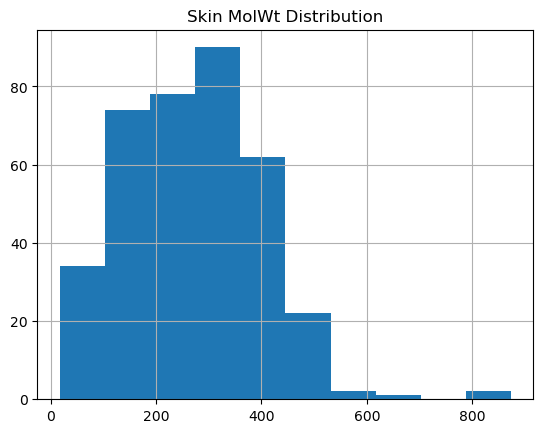

In [44]:
skin_final["MolWt"].hist()
plt.title("Skin MolWt Distribution")
plt.show()

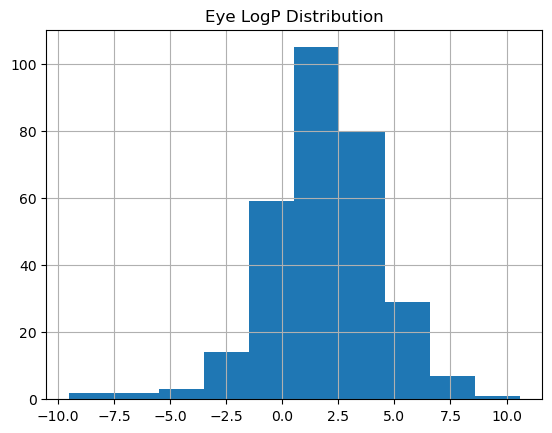

In [45]:
eye_final["LogP"].hist()
plt.title("Eye LogP Distribution")
plt.show()

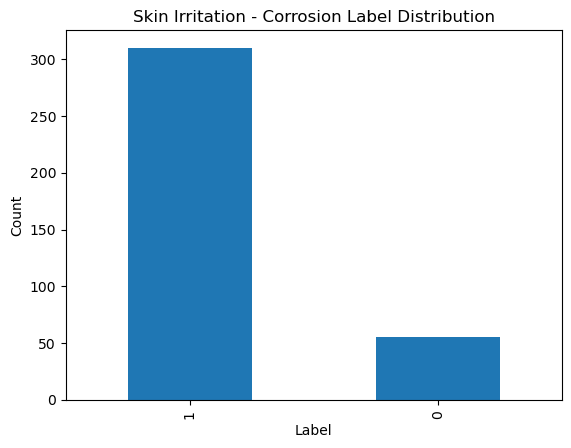

In [47]:
# label 분포 시각화 

import matplotlib.pyplot as plt 

skin_final["Label"].value_counts().plot(kind = "bar")
plt.title("Skin Irritation - Corrosion Label Distribution")
plt.xlabel("Label")
plt.ylabel("Count")
plt.show()

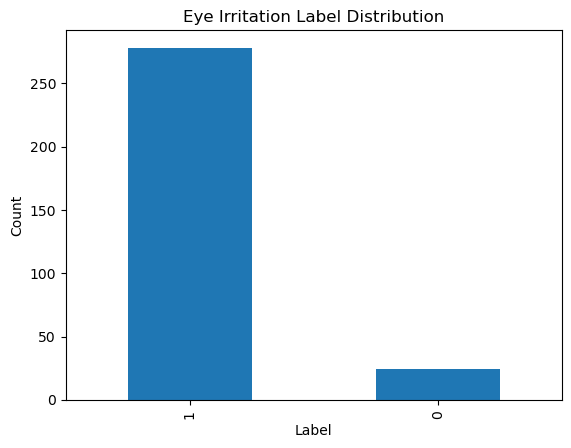

In [48]:
eye_final["Label"].value_counts().plot(kind="bar")
plt.title("Eye Irritation Label Distribution")
plt.xlabel("Label")
plt.ylabel("Count")
plt.show()

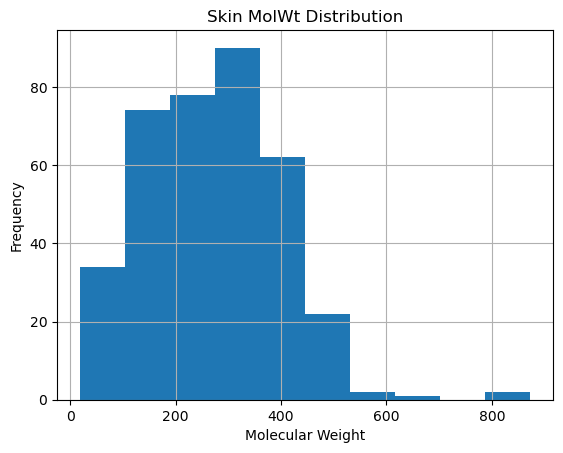

In [51]:
# descriptor histogram

skin_final["MolWt"].hist()
plt.title("Skin MolWt Distribution")
plt.xlabel("Molecular Weight")
plt.ylabel("Frequency")
plt.show()